In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import data_setup as ds

#### **Note:** You don't need to memorize every parameter for each plot — use an AI tool to help explain the parameters, functions, and how the code works whenever needed. Treat this notebook as a quick reference to come back to when you want to create a plot.

---
## Line Chart: A graph that connects data points with lines to show trends or changes over time.
---

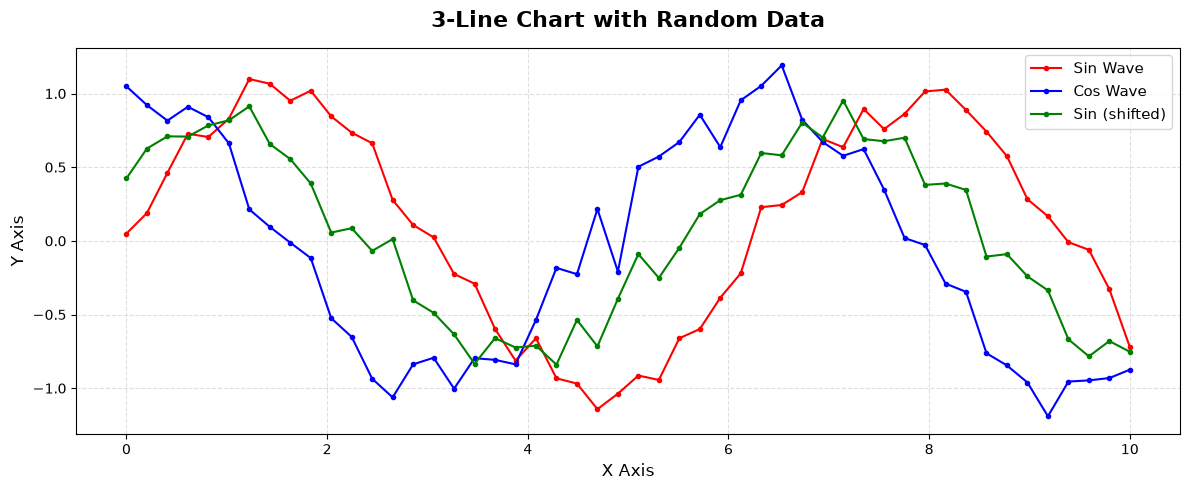

In [2]:
# ======== Random data ======== #
x, y1, y2, y3 = ds.plot_data()

"""
plt.plot(
    x, y1,
    color:                  # Line color (hex code) — controls the color of the plotted line itself.
    marker:                 # Marker shape for each data point (e.g. 'o' = circle, 's' = square, '^' = triangle).
    linestyle:              # Style of the line connecting points ('-' solid, '--' dashed, ':' dotted, '-.' dash-dot).
    linewidth:              # Thickness of the line, in points.
    label:                  # Name shown in the legend when plt.legend() is called.
    markersize:             # Size of each marker (data point).
    alpha:                  # Transparency of the line/markers (0 = fully transparent, 1 = fully opaque).
    markerfacecolor:        # Fill color inside each marker.
    markeredgecolor:        # Border/outline color around each marker.
)
"""

# ======== Line Charts ======== # 
fig, ax = plt.subplots(figsize=(12, 5))

# Line 1 — solid with circle markers
plt.plot(x, y1, color='red', marker='.', label='Sin Wave')

# Line 2 — dashed with square markers
plt.plot(x, y2, color='blue', marker='.', label='Cos Wave')

# Line 3 — dotted with triangle markers
plt.plot(x, y3, color='green', marker='.', label='Sin (shifted)')


ax.set_title('3-Line Chart with Random Data', fontsize=16, fontweight='bold', pad=15) # (label, fontsize, fontfamily, fontweight, color, pad, loc)
ax.set_xlabel('X Axis', fontsize=12)                                                  # (label, fontsize, color, labelpad)
ax.set_ylabel('Y Axis', fontsize=12)

ax.legend(fontsize=11)                                                                # (loc, ncols, fontsize, bbox_to_anchor)
ax.grid(True, linestyle='--', alpha=0.4)                                              # (axis:{x, y, both}, linestyle, linewidth, color, alpha)

plt.tight_layout()
plt.show()

---
## Bar Chart: A graph that uses rectangular bars to compare values across different categories.
---

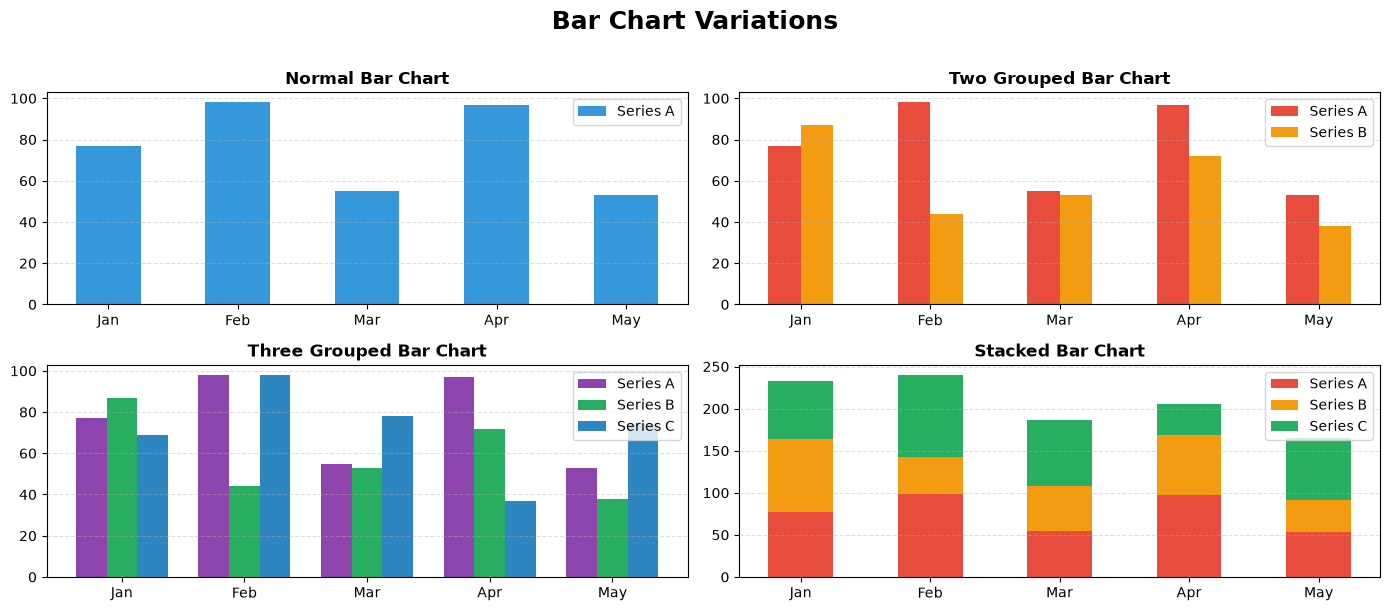

In [3]:
# Create Data
categories = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
width = 0.25
x, y1, y2, y3 = ds.bar_data(categories)

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle('Bar Chart Variations', fontsize=18, fontweight='bold', y=1.01)

"""
plt.bar(
    x, y1,
    width:                  # Width of each bar (as a fraction of the space between x-ticks).
    color:                  # Fill color of the bars (hex code).
    edgecolor:              # Color of the bar's border/outline.
    linewidth:              # Thickness of the bar's border.
    alpha=0.85:             # Transparency of the bars (0 = fully transparent, 1 = fully opaque).
    hatch:                  # Pattern drawn inside the bars (e.g. '/', '\\', 'x', '.') — empty means no pattern.
    label:                  # Name shown in the legend when plt.legend() is called.
)
"""

# ── 1. Normal Bar Chart ───────────────────────────────────────────────────────
ax = axes[0, 0]
ax.bar(x, y1, width=0.5, color='#3498DB', label='Series A')
ax.set_title('Normal Bar Chart', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 2. Two Grouped Bar Chart ──────────────────────────────────────────────────
ax = axes[0, 1]
ax.bar(x - width/2, y1, width=width, color='#E74C3C', label='Series A')
ax.bar(x + width/2, y2, width=width, color='#F39C12', label='Series B')
ax.set_title('Two Grouped Bar Chart', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 3. Three Grouped Bar Chart ────────────────────────────────────────────────
ax = axes[1, 0]
ax.bar(x - width, y1, width=width, color='#8E44AD', label='Series A')
ax.bar(x, y2,         width=width, color='#27AE60', label='Series B')
ax.bar(x + width, y3, width=width, color='#2E86C1', label='Series C')
ax.set_title('Three Grouped Bar Chart', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)

# ── 4. Stacked Bar Chart ──────────────────────────────────────────────────────
ax = axes[1, 1]
ax.bar(x, y1, width=0.5, color='#E74C3C', bottom=0, label='Series A')
ax.bar(x, y2, width=0.5, color='#F39C12', bottom=y1, label='Series B')
ax.bar(x, y3, width=0.5, color='#27AE60', bottom=y1 + y2, label='Series C')
ax.set_title('Stacked Bar Chart', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Horizontal Bar Plot & (ColorMaps & Annotations)

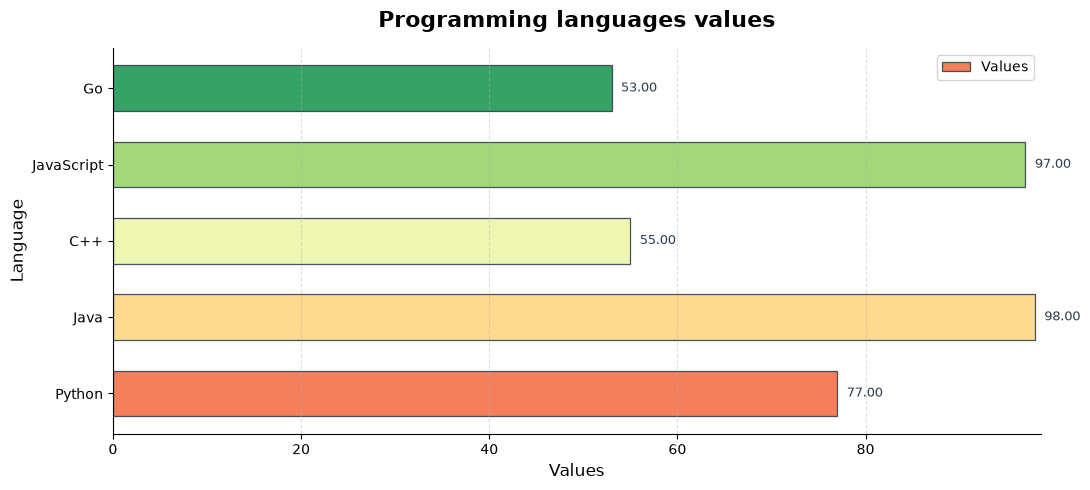

In [4]:
categories, values = ds.barh_data()

fig, ax = plt.subplots(figsize=(11, 5))

# Set the colomap for the plot
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(categories)))

"""The parameters is the same as bar chart"""
ax.barh(categories, values, height=0.6, color=colors, edgecolor='#2C3E50', linewidth=0.9, alpha=0.88, hatch='', label='Values')

# value labels at end of each bar
for i, val in enumerate(values):
    ax.text(val + 1, i, f'{val:.2f}', va='center', fontsize=9, color='#2C3E50')

ax.set_title('Programming languages values', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Values', fontsize=12)
ax.set_ylabel('Language', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, values.max() + 0.6)       # Set the limit of x axis plot

plt.tight_layout()
plt.show()

---
## Pie Chart: A circular chart divided into slices that shows how each category contributes to a whole (100%).
---

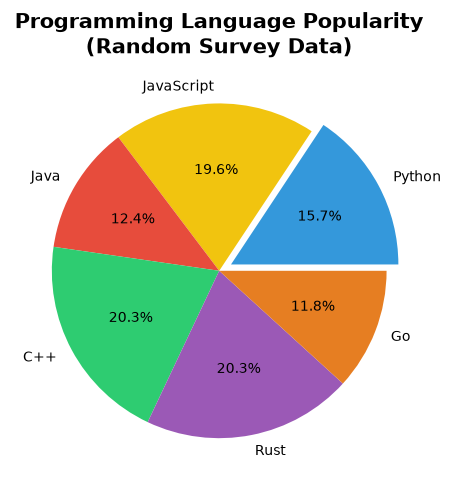

In [5]:
labels, x, colors, explode = ds.pie_data()

fig, ax = plt.subplots(figsize=(9, 5))

"""
wedges, texts, autotexts = ax.pie(
    x:                                                   # The data values — each slice's size is proportional to its value.
    labels:                                              # Text labels shown next to each slice.
    colors:                                              # List of colors, one for each slice/wedge.
    autopct:                                             # Format for displaying percentage values inside each slice.
    startangle:                                          # Rotates the starting angle of the first slice (in degrees, counter-clockwise from x-axis).
    explode:                                             # Offsets slices outward from the center to highlight/separate them.
    shadow:                                              # Adds a drop shadow beneath the pie for a 3D-like effect.
    wedgeprops:                                          # Styling for each wedge: border color, border thickness, and width<1 turns it into a donut chart.
    textprops:                                           # Styling for all text (labels & percentages): size, color, font, and weight.
    radius:                                              # Size of the pie chart (1.0 is default; >1 makes it bigger).
)
"""

# ===== Pie Chart ===== # 
wedges, texts, autotexts = ax.pie(x,  labels= labels, colors= colors, autopct= '%1.1f%%', explode= explode,)

ax.set_title('Programming Language Popularity\n(Random Survey Data)', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Stack Plot (Stacked Area Chart): A chart where multiple areas are stacked on top of each other to show both the total value and the contribution of each category over time.
---

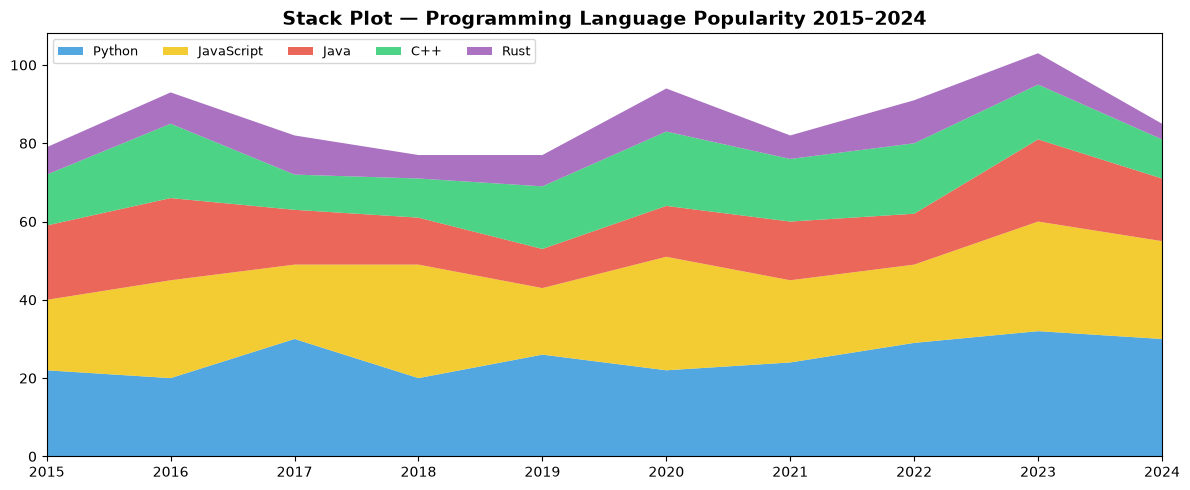

In [6]:
# ====== Create Random Data ======
x, python, js, java, cpp, rust, labels, colors = ds.stack_data()

"""
ax.stackplot(
    x, y1, y1, y2, y3, y4,
    labels:                         # Names for each layer, shown in the legend.
    colors:                         # List of colors, one for each layer/series.
    baseline:                       # How the layers are positioned vertically ('zero' = standard stack, 'sym' = centered/ThemeRiver, 'wiggle' = StreamGraph).
    alpha:                          # Transparency of the layers (0 = fully transparent, 1 = fully opaque).
    edgecolor:                      # Color of the line between layers.
    linewidth:                      # Thickness of the line between layers.
)
"""

# ===== Stack Plot ===== #
fig, ax = plt.subplots(figsize=(12, 5))

ax.stackplot(x, python, js, java, cpp, rust, labels=labels, colors=colors, alpha=0.85)

ax.set_title('Stack Plot — Programming Language Popularity 2015–2024', fontsize=14, fontweight='bold')
ax.set_xlim(x[0], x[-1])
ax.legend(loc='upper left', fontsize=9, ncol=5)

plt.tight_layout()
plt.show()

---
## Area Plot (Area Chart): Similar to a line chart, but the area under the line is filled, emphasizing the magnitude of change over time.
---

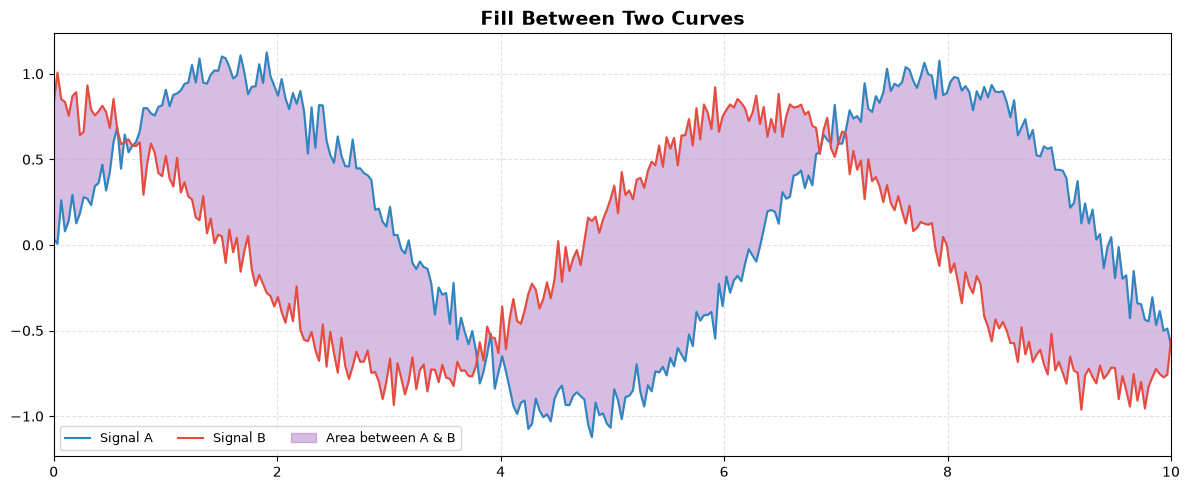

In [7]:
# ====== Create Random Data ====== # 
x, y1, y2 = ds.area_data()

"""
ax.fill_between(
    x, y1, y2,
    color:                  # Fill color of the area between the two curves.
    alpha:                  # Transparency of the filled area (0 = fully transparent, 1 = fully opaque).
    label:                  # Name shown in the legend when ax.legend() is called.
    where:                  # Condition that decides where to fill (e.g. y1 > y2) — None fills everywhere.
    interpolate:            # Smooths the fill edges at points where the two curves cross, instead of leaving jagged steps.
)
"""

# ===== Fill Between Two Curves ===== #
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(x, y1, color='#2E86C1', linewidth=1.5, label='Signal A')
ax.plot(x, y2, color='#E74C3C', linewidth=1.5, label='Signal B')

ax.fill_between(x, y1, y2, color='#8E44AD', alpha=0.35, label='Area between A & B')

ax.set_title('Fill Between Two Curves', fontsize=14, fontweight='bold')
ax.set_xlim(x[0], x[-1])
ax.legend(fontsize=9, ncol=3)
ax.grid(linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

---
## Histogram: A chart that groups continuous numerical data into intervals (bins) to show the distribution and frequency of values.
---

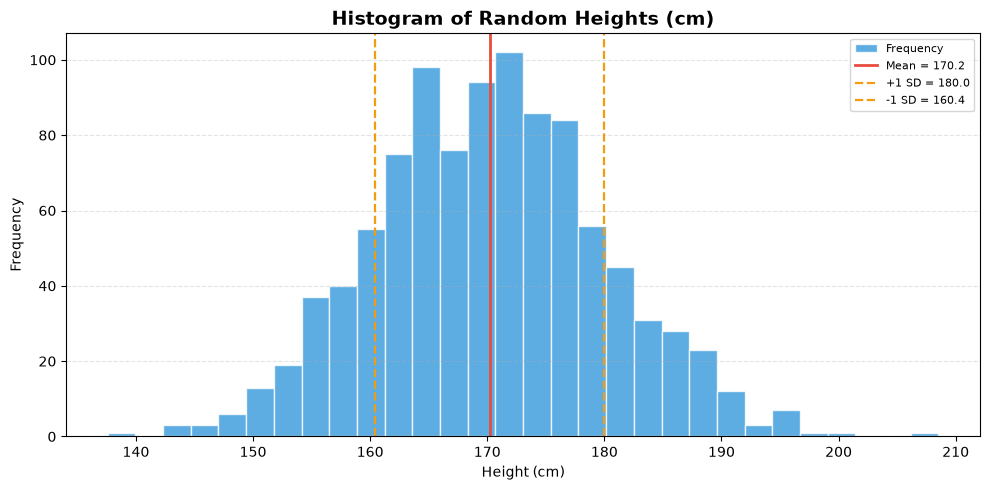

In [8]:
# ========= Create Random Data =========
x, mean, std = ds.histogram_data()

"""
ax.hist(
    x,
    bins:                   # Number of bars (or bin edges) the data is grouped into.
    density:                # If True, shows probability density instead of raw counts.
    cumulative:             # If True, each bar shows the running total up to that point.
    color:                  # Fill color of the bars.
    alpha:                  # Transparency of the bars (0 = fully transparent, 1 = fully opaque).
    label:                  # Name shown in the legend when ax.legend() is called.
    orientation:            # Direction of the bars ('vertical' or 'horizontal').
    edgecolor:              # Color of the bar's border/outline.
    linewidth:              # Thickness of the bar's border.
)
"""

# ===== Histogram ===== #
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(x, bins=30, color='#3498DB', alpha=0.80, label='Frequency', edgecolor='white')

# Addign vertical lines
"""
ax.axvline(
    x, ymin, ymax, color, lw, ls, label
)
"""
ax.axvline(mean, color='#E74C3C', lw=2.0, label=f'Mean = {mean:.1f}')
ax.axvline(mean + std, color='#F39C12', lw=1.6, ls='--', label=f'+1 SD = {mean+std:.1f}')
ax.axvline(mean - std, color='#F39C12', lw=1.6, ls='--', label=f'-1 SD = {mean-std:.1f}')

ax.set_title('Histogram of Random Heights (cm)', fontsize=14, fontweight='bold')
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

---
## Scatter Plot: A graph that displays individual data points using two numerical variables to show their relationship, correlation, or clustering.
---

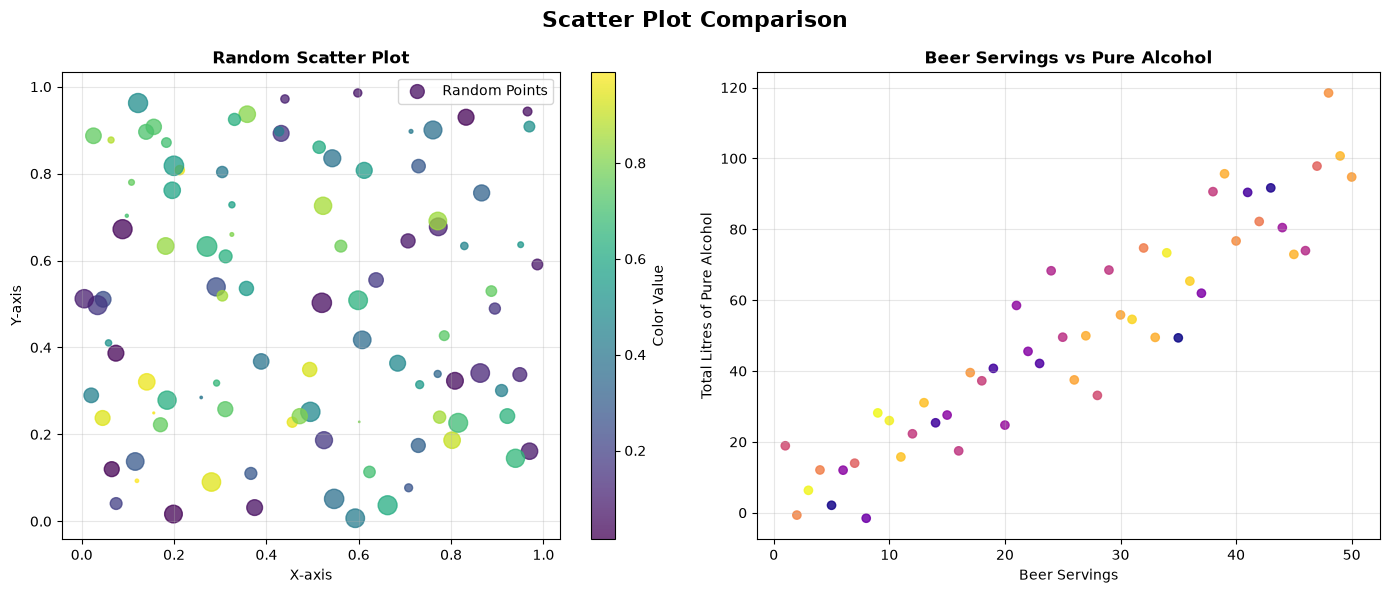

In [9]:
# ====================== Random Scatter Data ======================
x, y, s, c = ds.scatter_data1()

x_2, y_2, c_2 = ds.scatter_data2()

"""
ax.scatter(
    x, y,
    s:                      # Size of each point (can be a single number or an array for varying sizes).
    c:                      # Color of each point — can be a single color or an array mapped through a colormap.
    cmap:                   # Colormap used to translate 'c' values into colors (e.g. 'viridis', 'plasma').
    alpha:                  # Transparency of the points (0 = fully transparent, 1 = fully opaque).
    edgecolor:              # Border color around each point.
    linewidth:              # Thickness of each point's border.
    label:                  # Name shown in the legend when ax.legend() is called.
)
"""

# ====================== Create Figure with Subplots ======================
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# ------------------- Left Plot: Random Scatter -------------------
scatter = axs[0].scatter(x, y, s=s, c=c, cmap='viridis', alpha=0.75, label='Random Points')

axs[0].set_xlabel('X-axis')
axs[0].set_ylabel('Y-axis')
axs[0].set_title('Random Scatter Plot', fontweight='bold')
axs[0].grid(True, alpha=0.3)
axs[0].legend()
fig.colorbar(scatter, ax=axs[0], label='Color Value')

# ------------------- Right Plot: Beer vs Alcohol -------------------
axs[1].scatter(x_2, y_2, c=c_2, cmap='plasma', alpha=0.85)

axs[1].set_xlabel('Beer Servings')
axs[1].set_ylabel('Total Litres of Pure Alcohol')
axs[1].set_title('Beer Servings vs Pure Alcohol', fontweight='bold')
axs[1].grid(True, alpha=0.3)

plt.suptitle('Scatter Plot Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Box Plot: A chart that summarizes a dataset using the minimum, first quartile (Q1), median, third quartile (Q3), and maximum, helping identify spread and outliers.
---

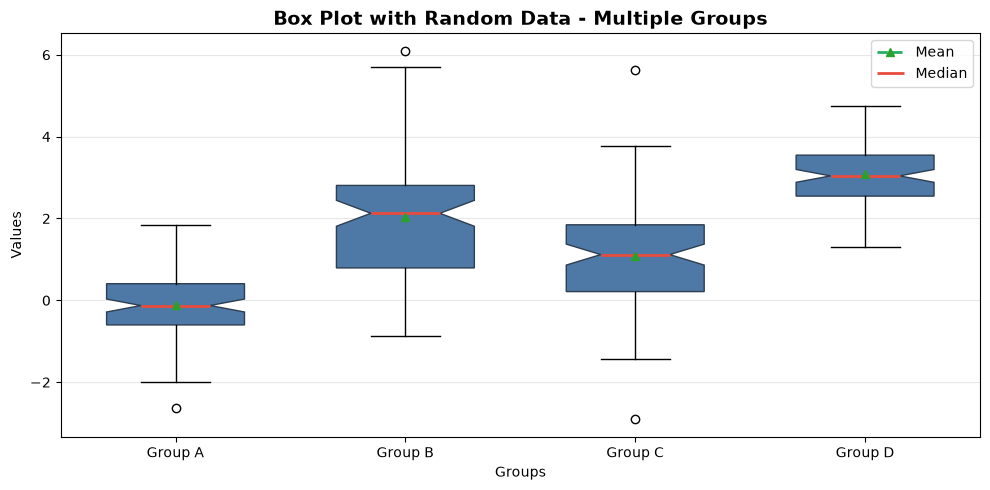

In [10]:
# ====================== Generate Random Data ======================
data, labels = ds.box_data()

"""
ax.boxplot(
    data,
    notch:                  # If True, draws a notch around the median to help compare medians between boxes.
    patch_artist:           # If True, fills each box with color instead of leaving it outlined only.
    tick_labels:            # Labels shown under each box on the x-axis.
    showmeans:              # If True, displays the mean of each group as well as the median.
    widths:                 # Width of each box.
    boxprops:               # Styling dict for the box itself (facecolor, edge color, linewidth).
    medianprops:            # Styling dict for the median line.
    meanprops:              # Styling dict for the mean line/marker.
)
"""

# ====================== Box Plot ======================
fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(
    data,
    notch=True,
    patch_artist=True,
    tick_labels=labels,
    showmeans=True,
    widths=0.6,
    boxprops=dict(facecolor='#4e79a7', color='#2c3e50'),
    medianprops=dict(color='#e74c3c', linewidth=2),
    meanprops=dict(color='#27ae60', linewidth=2, linestyle='--')
)

ax.set_title('Box Plot with Random Data - Multiple Groups', fontsize=14, fontweight='bold')
ax.set_ylabel('Values')
ax.set_xlabel('Groups')
ax.grid(axis='y', alpha=0.3)

ax.legend([bp['means'][0], bp['medians'][0]], ['Mean', 'Median'], loc='upper right')

plt.tight_layout()
plt.show()

---
## Violin Plot: A combination of a box plot and a density plot that shows both the distribution shape and summary statistics of the data.
---

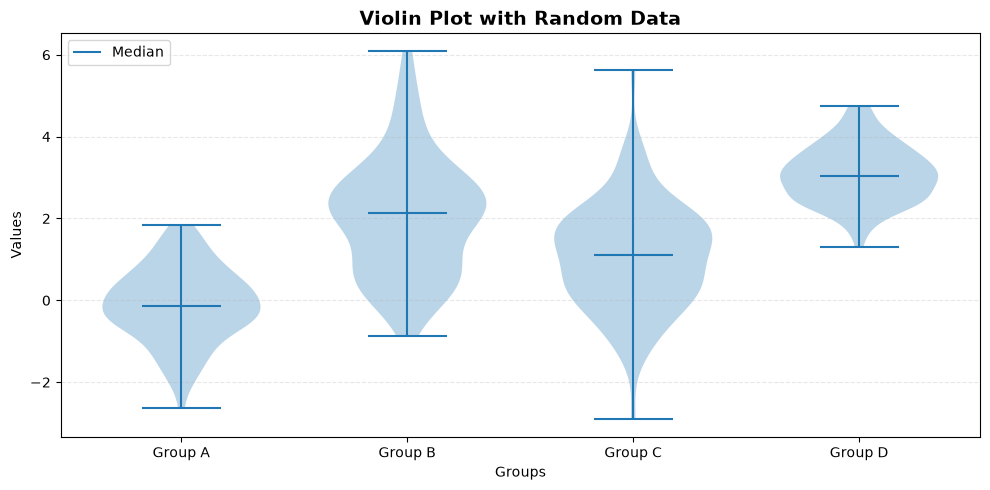

In [11]:
# ====================== Generate Random Data ======================
data, labels = ds.box_data()

"""
ax.violinplot(
    data,
    positions:               # X-axis position of each violin.
    widths:                  # Width of each violin.
    showmeans:               # If True, draws a line marking the mean of each group.
    showextrema:             # If True, draws lines marking the min and max of each group.
    showmedians:             # If True, draws a line marking the median of each group.
)
"""

# ====================== Violin Plot ======================
fig, ax = plt.subplots(figsize=(10, 5))

vp = ax.violinplot(
    data,
    positions=[1, 2, 3, 4],
    widths=0.7,
    showmedians=True
)

ax.set_title('Violin Plot with Random Data', fontsize=14, fontweight='bold')
ax.set_ylabel('Values')
ax.set_xlabel('Groups')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(labels)
ax.grid(axis='y', alpha=0.3, linestyle='--')

ax.legend([vp['cmedians']], ['Median'], loc='upper left')

plt.tight_layout()
plt.show()

---
## Heatmap: A chart that represents values using colors, making it easy to spot patterns, trends, correlations, or high/low values in a matrix or table.
---

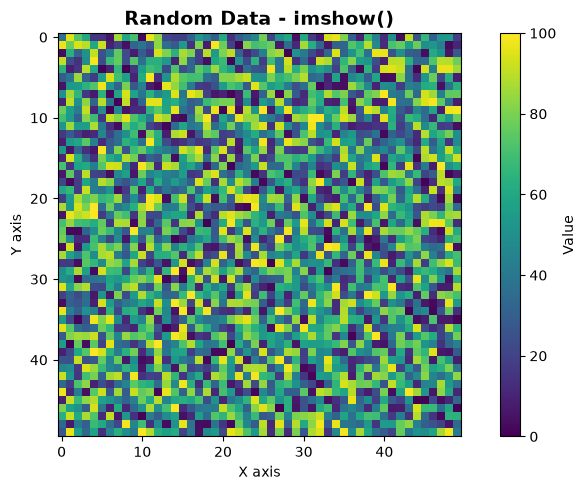

In [12]:
# Generate simple random 2D data
np.random.seed(42)
data = np.random.rand(50, 50) * 100

"""
ax.imshow(
    data,
    cmap:                   # Colormap used to translate values into colors (e.g. 'viridis', 'plasma').
    interpolation:          # How pixels are smoothed between data points (e.g. 'nearest', 'bilinear', 'bicubic').
    vmin:                   # Minimum data value mapped to the colormap (controls color scaling).
    vmax:                   # Maximum data value mapped to the colormap (controls color scaling).
)
"""

# ===== Heatmap ===== #
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(data, cmap='viridis', vmin=0, vmax=100)

ax.set_title('Random Data - imshow()', fontsize=14, fontweight='bold')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

plt.colorbar(im, ax=ax, label='Value')

plt.tight_layout()
plt.show()

---
## Additionals
---

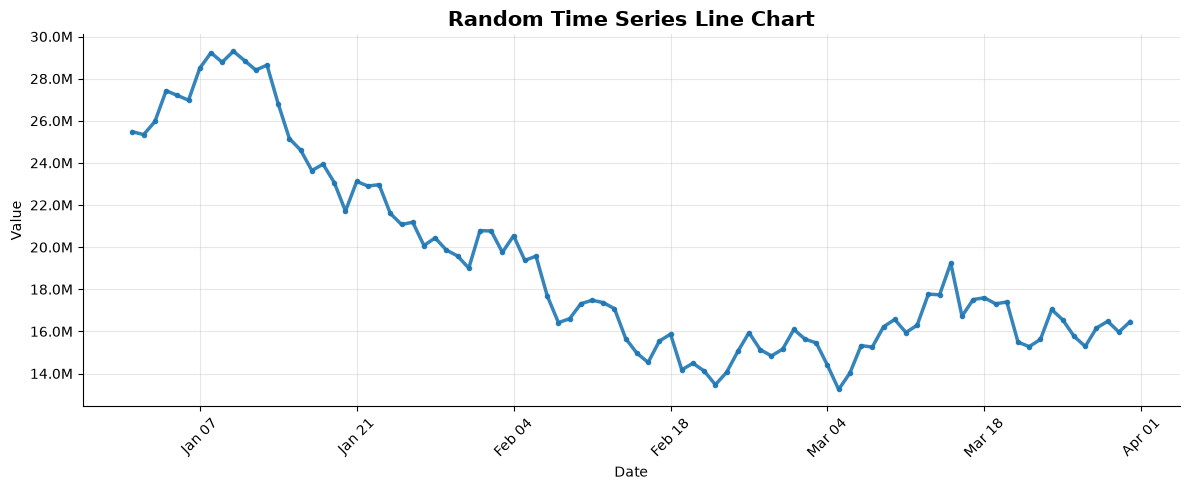

In [13]:
# Generate random time series data
dates, values = ds.time_series_data()

# Simple line chart
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dates, values, color='#1f77b4', linewidth=2.5, alpha=0.9, marker='.')

# Date formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Y-axis in Millions (e.g., 25.4M)
def millions_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'

ax.yaxis.set_major_formatter(millions_formatter)

# Styling
ax.set_title('Random Time Series Line Chart', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Value')

ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()